## **_Mission 5: ANZ Bank Analytics Challenge : Predicting Loan Status_**

### Business Case

In the banking sector, predicting whether a loan will default or be repaid is crucial for managing financial risks. When banks offer loans, they want to ensure that they can recover the money they lend. Incorrectly approving loans that will default or denying loans that would be repaid can have significant financial consequences.

By accurately predicting whether a loan is likely to default or not, banks can:

- Improve profitability by minimising defaults.
- Enhance customer experience by making timely, well-informed decisions about loan approvals.
- Reduce risks by identifying high-risk customers early and taking appropriate actions.
 

In this mission, we will use a loan dataset to predict whether a loan will be approved or default. The dataset includes features such as person's age, education, income, loan amount, loan interest rate, and credit score.

### Understanding and Loading the Dataset
**Dataset Overview:**
The dataset consists of the following columns:

- person_age: Age of the person applying for the loan.
- person_gender: Gender of the applicant.
- person_education: Education level of the applicant.
- person_income: Income of the applicant.
- person_emp_exp: Years of employment experience.
- person_home_ownership: Type of home ownership (Rent, Own, Mortgage).
- loan_amnt: Amount of the loan applied for.
- loan_intent: Purpose of the loan (e.g., Personal, Education, Medical).
- loan_int_rate: Interest rate on the loan.
- loan_percent_income: Percentage of income used for the loan.
- cb_person_cred_hist_length: Length of the applicant's credit history.
- credit_score: Credit score of the applicant.
- previous_loan_defaults_on_file: Whether the applicant has previous loan defaults.
- loan_status: Target variable (1 = Loan defaulted, 0 = Loan approved).

## **Task 4: Load the Data**

Loading the CSV file from Azure Blob Storage.

In [4]:
# Importing packages
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection string
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "Final_Mission_loan_data.csv"

# Create a BlobServiceClient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to a pandas DataFrame
df = pd.read_csv(StringIO(csv_content))

# Display the first few rows
df.head()

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 3, Finished, Available, Finished, False)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


##### **_The dataset has been loaded from a CSV file stored in Azure Blob Storage. The above output displays the first five rows of the DataFrame._**

## Task 5 : Exploratory Data Analysis (EDA)

##### **Task 5.1: Check for Missing Values and Data Types**

In [5]:
# Check for missing values
print(f"Missing values in each column:\n{df.isnull().sum()}\n")

# Check the data types of each column
print(f"Data types:\n{df.dtypes}")

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 4, Finished, Available, Finished, False)

Missing values in each column:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

Data types:
person_age                          int64
person_gender                      object
person_education                   object
person_income                       int64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                           int64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist

##### **_We are inspecting the data for any missing values and checking the data types of each column. There are no missing values._**

##### **Task 5.1.1: Summary Statistics**

In [6]:
# Generating summary statistics of numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])
summary_stats = numeric_df.describe()
summary_stats 

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 5, Finished, Available, Finished, False)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


##### _**We are generating summary statistics for numeric columns to understand the distribution of the data.**_

##### **Importing packages**

In [ ]:
##Importing seaborn matplotlib
!pip install seaborn matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 6, Finished, Available, Finished, False)

##### **Task 5.1.2: Checking for outliers**

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 7, Finished, Available, Finished, False)

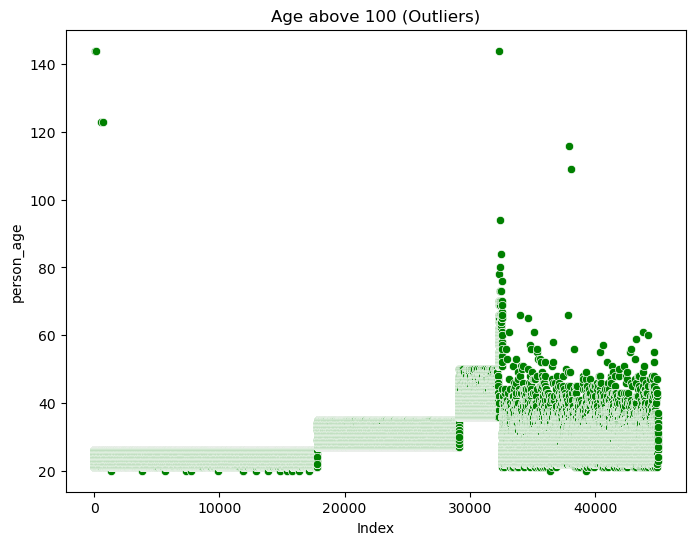

SynapseWidget(Synapse.DataFrame, 7b42198c-5948-4ab1-b861-b6e888c0bf64)


Total Number of Outliers: 7


In [ ]:
# Checking for outliers in the person_age column by using a scatter plot.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.index, y='person_age', data=df, color='green')
plt.title('Age above 100 (Outliers)')
plt.xlabel('Index')
plt.ylabel('person_age')
plt.show()

# Checking rows for person_age more than 100 (outliers)
outliers= df[df['person_age'] > 100]
display(outliers)

#Print number of outliers
print(f"\nTotal Number of Outliers: {len(outliers)}")

# Filtering out outlier ages
df_filtered = df[df['person_age'] <= 100]

##### _**Based on the summary statistics for the person_age column and as seen in the scatterplot, we identified seven records with ages between 109 and 144 years. These values are treated as outliers, as individuals of such advanced ages are highly unlikely to apply for loans. To prevent these anomalies from influencing our analysis, we have removed these records from the DataFrame.**_

##### **Task 5.2.1: Visualising the distribution of Loan Amount using a histogram**

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 8, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


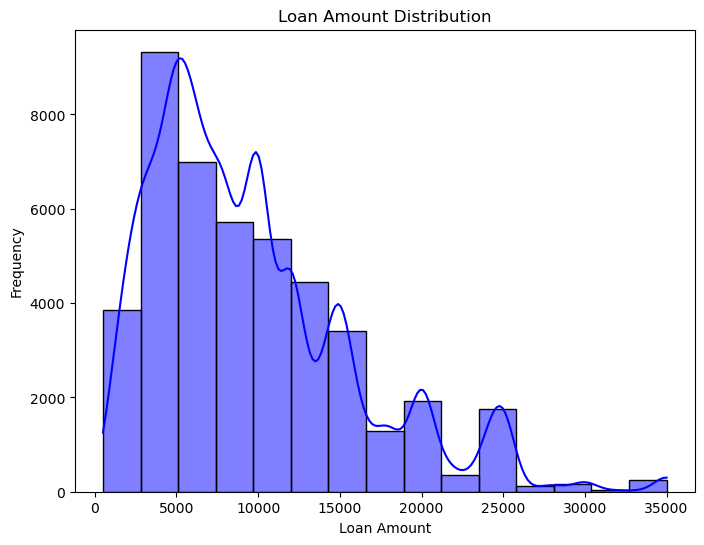

In [ ]:
# Loan amount distribution
plt.figure(figsize=(8, 6))
sns.histplot(df_filtered['loan_amnt'], bins=15, kde=True, color='blue')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

##### **_The histogram shows that loan amounts are heavily concentrated in the lower range, with the highest frequency of loans falling roughly between $3,000 and $8,000. As the loan amount increases, the frequency steadily decreases, indicating that larger loans are far less common. The smooth density curve also shows a right‑skewed distribution, meaning most borrowers take smaller loan amounts, while only a small number take very large loans (e.g., above $20,000). Overall, the plot suggests that the loan distribution is skewed toward lower values with a long tail extending toward higher loan amounts._**

##### **Task 5.2.2: Visualising the distribution of Credit Score using a histogram**

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 9, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


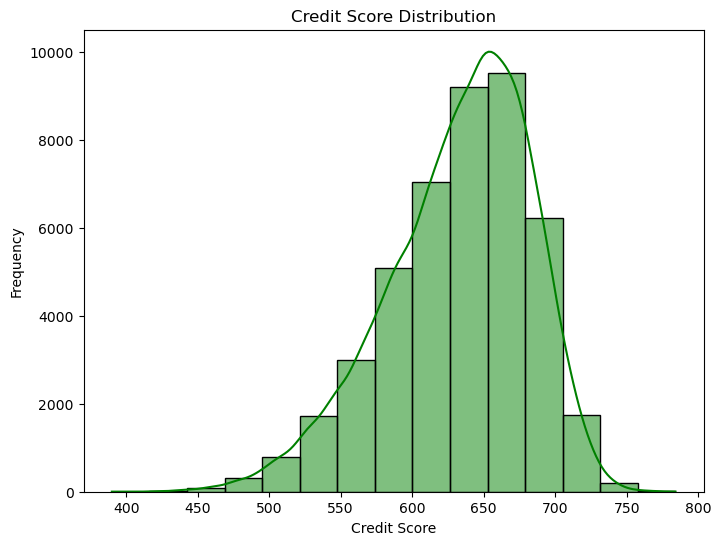

In [ ]:
# Credit score distribution
plt.figure(figsize=(8, 6))
sns.histplot(df_filtered['credit_score'], bins=15, kde=True, color='green')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

##### _**The histogram shows that credit scores in the dataset follow an approximately normal (bell‑shaped) distribution, centered around the 600–650 range. Most individuals fall within this middle band, indicating that average creditworthiness is clustered around typical credit score values. The frequencies drop off toward both lower and higher scores, with relatively few individuals scoring below 500 or above 750. Overall, the distribution suggests that the dataset is dominated by borrowers with moderate to good credit scores, with only a small number at the extreme ends.**_

##### **Task 5.2.3: Visualising the distribution of Loan Status using a countplot**

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 10, Finished, Available, Finished, False)

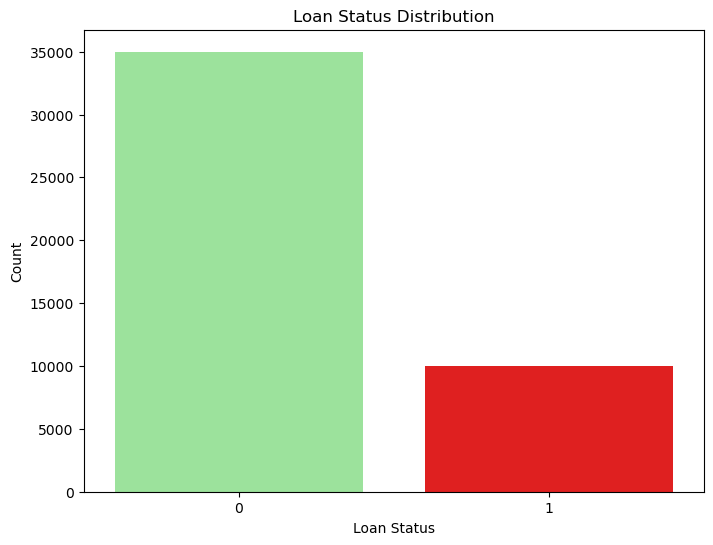

In [ ]:
# Loan Status distribution (target variable)
plt.figure(figsize=(8, 6))
sns.countplot(x='loan_status', data=df_filtered, palette=['lightgreen', 'red'])
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

##### **_The chart shows a strong imbalance between the two loan outcomes. Loan Status = 0, representing people whose loans were approved, makes up the largest portion of the dataset, as indicated by the tall light-green bar on the left. In contrast, Loan Status = 1, representing people who defaulted on their loans, appears much less frequently, shown by the shorter red bar. This indicates that most borrowers successfully repay their loans, while only a smaller group ends up defaulting._**

##### **Task 5.3 : Correlation Heatmap**

Visualizing the correlations between numerical features.

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 11, Finished, Available, Finished, False)

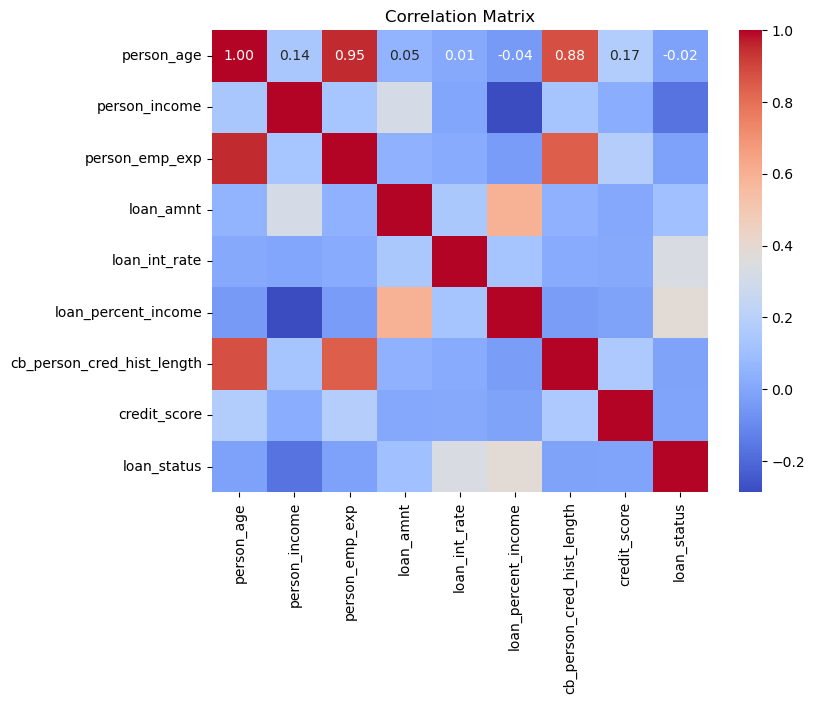

In [ ]:
# Select only numeric columns for correlation
numeric_df = df_filtered.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

##### _**The correlation matrix indicates several strong relationships among the numerical features.**_ 
##### _Key observations include:_

- ##### _**person_age**, **person_income**, and **person_emp_exp** show strong positive correlations with each other, suggesting these variables tend to increase together._
- ##### _**loan_amnt, loan_int_rate,** and **loan_percent_income** also exhibit moderate to strong correlations, reflecting expected relationships between **loan size, interest rate,** and **income percentage**._
- ##### **cb_person_cred_hist_length** shows a moderate positive correlation with **person_age,** which is intuitive since older individuals tend to have longer credit histories._
- ##### With respect to the target variable **loan_status**, correlations are generally weak, with the highest being:- 
- - ##### **loan_percent_income (~0.38)**, indicating that borrowers with higher income-to-loan ratios are more likely to default.
- - ##### **loan_int_rate (~0.33)**, showing that higher interest rates are associated with a greater chance of default.
- ##### Other features exhibit very low or near-zero correlation with **loan_status**, suggesting they may have limited direct predictive power on their own.


## Task 6 : Data Preprocessing

##### **Task 6.1 : Handling missing values**

In [ ]:
# Checking missing values
df_filtered.isnull().sum()

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 12, Finished, Available, Finished, False)

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

##### **_This code is to check our data set for any missing values, there are no missing values._**
 

##### **Task 6.2 : Encode categorical variables**

In [ ]:
# Encoding categorical variables 
df_encoded = pd.get_dummies(
    df_filtered,
    columns=['person_gender', 'person_education', 'person_home_ownership', 'loan_intent',
        'previous_loan_defaults_on_file'],
    drop_first=True
)
print(df_encoded.columns)

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 13, Finished, Available, Finished, False)

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status', 'person_gender_male',
       'person_education_Bachelor', 'person_education_Doctorate',
       'person_education_High School', 'person_education_Master',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'previous_loan_defaults_on_file_Yes'],
      dtype='object')


##### **_This code has changed our text data, like gender and education, into numbers so the model can understand it. Machine learning models can only work with numerical data, so categorical values need to be converted for training the model. It creates new columns for each category and removes one category to prevent duplication._**

##### **Task 6.3 : Split the data into features (X) and target (y)**

In [ ]:
# Spliting the dataset into features (X) and target variable (y)
X = df_encoded.drop('loan_status',axis=1)
y = df_encoded['loan_status']
print(X.shape)
print(y.shape)

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 14, Finished, Available, Finished, False)

(44993, 22)
(44993,)


##### **_This code we have used separates the dataset into features (X) and target variable (y). The features (X) contain all the input variables used to make predictions, while target variable (y) contains the outcome we want to predict, which is loan status._**

##### **Task 6.4 : Split the data into training (80%) and testing (20%) sets**

In [ ]:
# Spliting the data into training (80%) and testing (20%) sets
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the split data
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 15, Finished, Available, Finished, False)

Training Data: (35994, 22), Testing Data: (8999, 22)


##### **_We used this code to split the dataset into 80% training data (35,994 rows & 22 Columns) and 20% testing data (8,999 & 22 columns). This was done using the test_train_split function, which separates the data into training and testing sets. The model learns from the training data and is then tested on the remaining data._**

## Task 7 : Train Multiple Models

##### **Task 7.1 : Logistic Regression Model**

In [ ]:
# Training Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Initialize Logistic Regression model
log_reg_model = LogisticRegression()

# Train the model
log_reg_model.fit(X_train, y_train)

# Predict on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}\n")

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log_reg, labels=[0, 1])
cm_log_df = pd.DataFrame(cm_log,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_log_df)

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 16, Finished, Available, Finished, False)

Logistic Regression Accuracy: 0.8238693188132015

                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6662                      340
Actual: 1 (Positive)                     1245                      752


##### **_A Logistic Regression model was trained using the training data to predict loan status and then tested on the testing data. Its performance was evaluated using accuracy and a confusion matrix. The model achieved an accuracy of approximately 84.8% showing good overall performance. While most predictions were correct, some default cases were incorrectly predicted as approved, which could be a risk in real- world situations._**
 

##### **Task 7.2 : Random Forest Classifier** 

In [ ]:
# Training Random Forest Classifier with 100 Estimators

from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy_100 = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy with 100 estimators: {rf_accuracy_100}\n")

# Confusion Matrix

cm_rf_100 = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
cm_rf_df_100 = pd.DataFrame(cm_rf_100,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_rf_df_100)

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 17, Finished, Available, Finished, False)

Random Forest Accuracy with 100 estimators: 0.9289921102344705

                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6832                      170
Actual: 1 (Positive)                      469                     1528


##### **Task 7.2.1 : Tuning Random Forest**

In [ ]:
# Tuning Random Forest Classifier with 200 estimators 

from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf_tuned = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy_200 = accuracy_score(y_test, y_pred_rf_tuned)
print(f"Random Forest Accuracy with 200 estimators: {rf_accuracy_200}\n")

# Confusion Matrix

cm_rf_200 = confusion_matrix(y_test, y_pred_rf_tuned, labels=[0, 1])
cm_rf_df_200 = pd.DataFrame(cm_rf_200,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_rf_df_200)

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 18, Finished, Available, Finished, False)

Random Forest Accuracy with 200 estimators: 0.9294366040671186

                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6837                      165
Actual: 1 (Positive)                      470                     1527


##### **_A Random Forest model was trained using the training data and tested on the testing data to predict the loan status. To improve performance two values for the number of estimators (100 and 200) were tested. The model with slightly better performance was 200 estimators. The final model achieved an accuracy of approximately 92.9% showing a strong overall performance. The confusion matrix shows that the best performing model correctly predicted 6,837 approved loans and 1,527 default cases. There were 165 cases where approved loans were incorrectly predicted as defaulted and 470 cases where defaulted loans were incorrectly predicted as approved loans. Overall, the model performed well, with most loan outcomes predicted correctly and fewer errors compared to Logistic Regression. However, some default cases were still missed, which could be important in real-world lending scenario._**

#####

##### **Task 7.3 : Gradient Booster Classifier**

In [ ]:
# Training Gradient Booster Classifier with 200 estimators

from sklearn.ensemble import GradientBoostingClassifier

# Initialize Random Forest model
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
gb_accuracy_200 = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {gb_accuracy_200}\n")

# Confusion Matrix

cm_gb_200 = confusion_matrix(y_test, y_pred_gb, labels=[0, 1])
cm_gb_df_200 = pd.DataFrame(cm_gb_200,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_gb_df_200)

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 19, Finished, Available, Finished, False)

Gradient Boosting Accuracy: 0.9294366040671186

                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6812                      190
Actual: 1 (Positive)                      445                     1552


##### **Task 7.3.1 : Tuning Gradient Boost**

In [ ]:
# Tuning Gradient Booster Classifier with 600 estimators

from sklearn.ensemble import GradientBoostingClassifier

# Initialize Random Forest model
gb_model = GradientBoostingClassifier(n_estimators=600, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb_tuned = gb_model.predict(X_test)

# Evaluate the model
gb_accuracy_600 = accuracy_score(y_test, y_pred_gb_tuned)
print(f"Gradient Boosting Accuracy with 600 estimators: {gb_accuracy_600}\n")

# Confusion Matrix

cm_gb_600 = confusion_matrix(y_test, y_pred_gb_tuned, labels=[0, 1])
cm_gb_df_600 = pd.DataFrame(cm_gb_600,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_gb_df_600)

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 20, Finished, Available, Finished, False)

Gradient Boosting Accuracy with 600 estimators: 0.9331036781864651

                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6810                      192
Actual: 1 (Positive)                      410                     1587


##### **_A Gradient Boosting model was trained using the training data to predict loan status. The model was then used to make predictions on the testing data, and its performance was evaluated using accuracy and a confusion matrix. To optimise performance, two different values of estimators (200 and 600) were tested, with 600 estimators producing the best results. The model achieved an accuracy of approximately 93.3%, making it the highest performing model. The confusion matrix shows that the model correctly predicted 6,810 approved loans and 1587 defaulted loans. There were 192 cases where approved loans were incorrectly predicted as defaulted and 410 cases where defaulted loans were incorrectly predicted as approved, which could be important in a real world scenario._**

## Task 8: Evaluate the Models

##### Task 8.1 : Create table with Actual vs Predicted values for each model

In [ ]:
# Create a DataFrame for Actual vs Predicted Values for each models
df_results = pd.DataFrame({
    'Actual_Loan_Status': y_test,
    'Predicted_Loan_Status_Logistic_Regression': y_pred_log_reg,
    'Predicted_Loan_Status_Random_Forest_100_Estimators': y_pred_rf,
    'Predicted_Loan_Status_Random_Forest_Tuned_200_estimators': y_pred_rf_tuned,
    'Predicted_Loan_Status_Gradient_Boosting_200_estimators': y_pred_gb,
    'Predicted_Loan_Status_Gradient_Boosting_Tuned_600_estimators': y_pred_gb_tuned
})

# Display the table
display(df_results.head())

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 21, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 1c5e5630-b03e-412f-bdeb-61a4016c5add)

##### _**This code creates a DataFrame that combines the actual loan status values with the predicted results from all the models, allowing an easy side-by-side comparison of how each model performed on the same test data.**_

##### 

##### **Task 8.2 : Compare the performance of all three models using Accuracy and Confusion Matrix**

In [ ]:
# Create a combined comparison table summarizing the performance of all three models
performance_data = {
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [log_reg_accuracy, rf_accuracy_200, gb_accuracy_600],
    "True Negatives": [cm_log[0][0], cm_rf_200[0][0], cm_gb_600[0][0]],
    "False Positives": [cm_log[0][1], cm_rf_200[0][1], cm_gb_600[0][1]],
    "False Negatives": [cm_log[1][0], cm_rf_200[1][0], cm_gb_600[1][0]],
    "True Positives": [cm_log[1][1], cm_rf_200[1][1], cm_gb_600[1][1]]
}

performance_df = pd.DataFrame(performance_data)
print("\nModel Performance Comparison Table:")
display(performance_df)


StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 22, Finished, Available, Finished, False)


Model Performance Comparison Table:


SynapseWidget(Synapse.DataFrame, cdaa2be0-8abc-4087-b413-498b2a647d34)

##### **_This code creates a summary table that compares the performance of the three models by calculating their accuracy and breaking down the confusion matrix into true/false positives and negatives._**

## Task 9 : Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Accuracy
acc_log = log_reg_accuracy
acc_rf = rf_accuracy_200
acc_gb = gb_accuracy_600

# Confusion matrices
cm_log = cm_log
cm_rf = cm_rf_200
cm_gb = cm_gb_600

# Comparison table
print("\nModel Performance Comparison Table:")
df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [acc_log, acc_rf, acc_gb],
    "False Negatives": [cm_log[1][0], cm_rf[1][0], cm_gb[1][0]]
})

display(df)

# Best model
best = df.loc[df["Accuracy"].idxmax(), "Model"]
print("\nBest Model:", best)

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, 24, Finished, Available, Finished, False)


Model Performance Comparison Table:


SynapseWidget(Synapse.DataFrame, 4301e34c-dac8-4d1f-ad8f-9ce430cbc954)


Best Model: Gradient Boosting


- ##### _**Gradient Boosting is the best-performing model overall with the highest accuracy (93.3%).**_
- ##### _**It achieves the lowest number of false negatives (410) — the most important metric for default prediction because it means fewer defaulters are incorrectly approved.**_
- ##### _**It also delivers the highest number of true positives (1,587), correctly identifying more genuine defaulters than Random Forest (1,527) and Logistic Regression (1,031).**_
- ##### _**Although Random Forest has the fewest false positives (165), indicating fewer “false alarms,” it still misses more defaulters (470 false negatives) than Gradient Boosting.**_
- ##### _**Logistic Regression performs the weakest overall with lowest accuracy (0.8477) and highest false negatives (966).**_
- ##### _**Overall, Gradient Boosting provides the best risk‑focused performance, balancing high accuracy, lower misclassification of high‑risk customers, and strong detection of true defaulters.**_

## Task 10: Creating a Table in the Microsoft Fabric DataLakehouse

In [ ]:
# Import necessary libraries
from pyspark.sql import SparkSession

# Create or get the existing Spark session
spark = SparkSession.builder \
    .appName("PySpark Basic Example") \
    .getOrCreate()

# Check the Spark version
print(f"Spark Version: {spark.version}")

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, -1, Cancelled, , Cancelled, True)

In [ ]:
# 1. Convert your results to a Spark DataFrame
df_results_spark = spark.createDataFrame(df_results)

# 2. Create the temp view
df_results_spark.createOrReplaceTempView("df_results_spark_view")

# 3. Read it back
df_spark = spark.table("df_results_spark_view")

# 4. Write to the lakehouse
# Save to lakehouse table (Team 3)
df_spark.write.mode("overwrite").option("overwriteSchema", "true").format("delta").saveAsTable("Team3_Mission5_Table")

print("✅ Table 'Team3_Mission5_Table' saved successfully to Mission_ready_data_lakehouse!")

StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, -1, Cancelled, , Cancelled, True)

In [ ]:

# Verify the table
spark.table("Team3_Mission5_Table").show(5)


StatementMeta(, 6c2f3494-2f99-4b93-8e54-b94b3fe88ba1, -1, Cancelled, , Cancelled, True)

## Task 11: Conclusion

- ##### _**Based on the results of the three models, Gradient Boosting performed the best in predicting loan defaults.**_
- ##### _**It achieved the highest accuracy and also produced the fewest false negatives, which is very important in a banking environment.**_
- ##### _**A false negative means that a borrower who is likely to default is incorrectly predicted as safe. This type of error can be costly for a bank because it may lead to approving risky loans.**_
- ##### _**For this reason, the Gradient Boosting model is the most suitable model for this task. It not only gave the best overall performance, but it also did a better job of identifying high-risk borrowers compared with Logistic Regression and Random Forest.**_
- ##### _**In practice, this means the bank can use this model to support better lending decisions, reduce the chance of loan losses, and improve risk management.**_
- ##### _**It can also help the bank make faster decisions for lower-risk applicants while paying closer attention to customers who may be more likely to default.**_
